In [1]:
"""
Main notebook for running tracking scores.

TODO:
Each parameter needs to be normalised from 0 to 1 across the set of compared algorithms, yielding a maximum composite skill score of 4.
Higher-scoring algorithms are those that efficiently detect storms with greater current or future severe threat while minimising detection of weak,
short-lived storms.
"""

'\nMain notebook for running tracking scores.\n\nTODO:\nEach parameter needs to be normalised from 0 to 1 across the set of compared algorithms, yielding a maximum composite skill score of 4.\nHigher-scoring algorithms are those that efficiently detect storms with greater current or future severe threat while minimising detection of weak,\nshort-lived storms.\n'

In [1]:
import glob

from matplotlib import pyplot as plt
import cartopy.crs as ccrs

from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import best_track
import readers

In [5]:
import importlib
importlib.reload(best_track)
importlib.reload(readers)

<module 'readers' from '/home/548/jss548/dev/projects/track_scores/readers.py'>

In [6]:
def run_scores(df, best_track_df):
    """
    Calculate tracking scores for each track in the DataFrame.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with track data
    best_track_df : pandas.DataFrame
        DataFrame with best track data

    Returns
    -------
    tuple of lists
        consistency_scores, duration_scores, linearity_scores, best_track_scores
    """

    unique_track_ids = df['track_id'].unique()
    consistency_scores = []
    duration_scores = []
    linearity_scores = []
    best_track_scores = []

    minimum_length = 2

    for track_id in unique_track_ids:
        subset_df = df[df['track_id'] == track_id]
        subset_n = len(subset_df)
        if subset_n < minimum_length:
            continue

        #consistency score
        subset_area = np.array(subset_df['area'])
        consistency_scores.append(np.sum(np.abs(subset_area[1:]-subset_area[:-1])/subset_area[:-1]) / (subset_n - 1))

        #duration score
        duration_scores.append((np.max(subset_df['timestamp'])-np.min(subset_df['timestamp'])).total_seconds() / 60)

        #linearity score
        #calculate best-fit line for lat-lon points using np.polyfit
        subset_lon = np.array(subset_df['lon'])
        subset_lat = np.array(subset_df['lat'])
        if len(subset_lon) < 3:
            linearity_scores.append(np.nan)
            continue
        p = np.polyfit(subset_lon, subset_lat, 1)
        #calculate r-squared value of subset points to the polyfit p
        lat_fit = np.polyval(p, subset_lon)
        ss_res = np.sum((subset_lat - lat_fit) ** 2)
        ss_tot = np.sum((subset_lat - np.mean(subset_lat)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        linearity_scores.append(r_squared)

    #loop through each row in best_track_df and check if track_id is the same as init_track_id
    best_track_scores = 0
    for index, row in best_track_df.iterrows():
        if row['initial_track_id'] == row['track_id']:
            best_track_scores += 1
        else:
            best_track_scores += 0.5
    #divide best_track_scores by number of cell in original df
    best_track_scores = best_track_scores/len(df)

    return consistency_scores, duration_scores, linearity_scores, best_track_scores

def plot_track(ax, df, track_ids=None, title='Storm Tracks', extent=None):
    """
    Plot all storm tracks on one plot.
    
    Parameters:
    -----------
    ax: matplotlib axis
        Axis to plot on
    df : pandas.DataFrame
        Original DataFrame with track data
    track_ids : list, optional
        List of specific track_ids to plot. If None, plots all tracks.
    extent: list, optional
        [lon_min, lon_max, lat_min, lat_max] to set plot extent
    """
    
    if track_ids is None:
        track_ids = df['track_id'].unique()
        
    # Generate distinct colors for each track
    colors = plt.cm.tab20(np.linspace(0, 1, len(track_ids)))
    
    # add cartopy coastlines to the plot
    ax.coastlines(resolution='10m')

    for idx, track_id in enumerate(track_ids):
        color = colors[idx]
        
        # Get track data
        track_data = df[df['track_id'] == track_id].sort_values('timestamp')

        # Extract observed positions
        x_obs = track_data['lon'].values
        y_obs = track_data['lat'].values
        
        # Plot observed track
        ax.plot(x_obs, y_obs, 'o-', color=color, label=f'Track {track_id}', 
                markersize=2, linewidth=0.5, alpha=0.7)

    # Labels and formatting
    ax.set_xlabel('X (deg)', fontsize=12)
    ax.set_ylabel('Y (deg)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.legend(fontsize=10, loc='best', ncol=max(1, len(track_ids)//10))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    
    #set lat bounds
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Algorithm            Consistency     Duration        Linearity       Best Track     
TITAN                0.394           19.212          0.758           0.630          
WW                   0.000           25.397          0.707           0.735          
AINT 1               0.358           29.630          0.679           0.789          
AINT National        0.317           14.705          0.843           0.580          


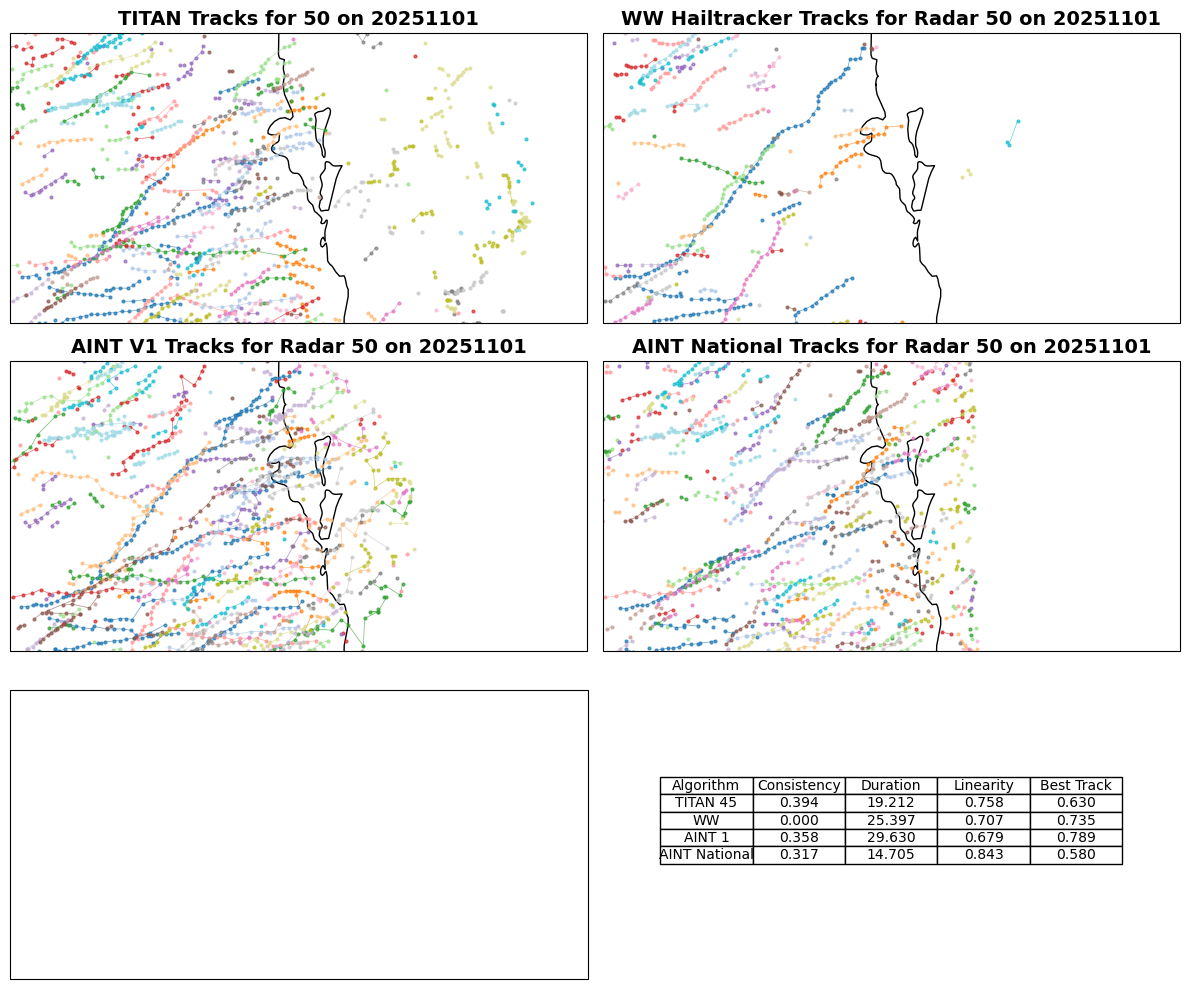

In [11]:
#evalute an events
myproj = ccrs.PlateCarree()
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 10), subplot_kw={'projection': myproj})

event_date = '20251101'
ww_radar_id = '050'
titan_radar_name = 'marburg'
aint_radar_id = '50'
extent = [152.25, 154.25, -28.5, -26.5]  # [lon_min, lon_max, lat_min, lat_max]

#TITAN ASCII data
reflectivity_lvl = 45
titan_dataset_ffn = f'/g/data/kl02/jss548/track_scores/titan/ascii/{titan_radar_name}2025_{reflectivity_lvl}/{event_date}.storms_to_tifs'
titan_track_df = readers.load_titan_ascii(titan_dataset_ffn)
titan_best_track_df = best_track.main(titan_track_df, n_iterations=5)
plot_track(ax1, titan_track_df, title=f'TITAN Tracks for {aint_radar_id} on {event_date}', extent=extent)
titan_consistency_scores, titan_duration_scores, titan_linearity_scores, titan_best_track_scores = run_scores(titan_track_df, titan_best_track_df)

#WW chronos data
ww_dataset_ffn = f'/g/data/kl02/jss548/track_scores/ww_hailtracker/{ww_radar_id}_{event_date}.csv'
ww_track_df = readers.read_ww_hailtracker(ww_dataset_ffn)
ww_best_track_df = best_track.main(ww_track_df, n_iterations=5)
plot_track(ax2, ww_track_df, title=f'WW Hailtracker Tracks for Radar {aint_radar_id} on {event_date}', extent=extent)
ww_consistency_scores, ww_duration_scores, ww_linearity_scores, ww_best_track_scores = run_scores(ww_track_df, ww_best_track_df)

#AINT data
aint1_dataset_ffn = f'/g/data/kl02/jss548/aint_testing/aint_v1/{aint_radar_id}/{event_date[0:4]}/{aint_radar_id}_{event_date}_aint.csv'
aint1_track_df = readers.load_aint(aint1_dataset_ffn)
aint1_best_track_df = best_track.main(aint1_track_df, n_iterations=5)
plot_track(ax3, aint1_track_df, title=f'AINT V1 Tracks for Radar {aint_radar_id} on {event_date}', extent=extent)
aint1_consistency_scores, aint1_duration_scores, aint1_linearity_scores, aint1_best_track_scores = run_scores(aint1_track_df, aint1_best_track_df)

#AINT national data
aint2_dataset_ffn = f'/g/data/kl02/jss548/aint_testing/aint_national/{aint_radar_id}/{event_date}/data/{aint_radar_id}_{event_date}_merged.tracks.csv'
aint2_track_df = readers.load_aint_national(aint2_dataset_ffn)
aint2_best_track_df = best_track.main(aint2_track_df, n_iterations=5)
plot_track(ax4, aint2_track_df, title=f'AINT National Tracks for Radar {aint_radar_id} on {event_date}', extent=extent)
aint2_consistency_scores, aint2_duration_scores, aint2_linearity_scores, aint2_best_track_scores = run_scores(aint2_track_df, aint2_best_track_df)

#PyFLEXTRKR

#print a table of the scores from each algorithm
print(f"{'Algorithm':<20} {'Consistency':<15} {'Duration':<15} {'Linearity':<15} {'Best Track':<15}")
print(f"{'TITAN':<20} {np.mean(titan_consistency_scores):<15.3f} {np.mean(titan_duration_scores):<15.3f} {np.nanmean(titan_linearity_scores):<15.3f} {titan_best_track_scores:<15.3f}")
print(f"{'WW':<20} {np.mean(ww_consistency_scores):<15.3f} {np.mean(ww_duration_scores):<15.3f} {np.nanmean(ww_linearity_scores):<15.3f} {ww_best_track_scores:<15.3f}")
print(f"{'AINT 1':<20} {np.mean(aint1_consistency_scores):<15.3f} {np.mean(aint1_duration_scores):<15.3f} {np.nanmean(aint1_linearity_scores):<15.3f} {aint1_best_track_scores:<15.3f}")  
print(f"{'AINT National':<20} {np.mean(aint2_consistency_scores):<15.3f} {np.mean(aint2_duration_scores):<15.3f} {np.nanmean(aint2_linearity_scores):<15.3f} {aint2_best_track_scores:<15.3f}")  

#plot a table of the scores for each algorthim in ax6
ax6.axis('off')
table_data = [
    [f'TITAN {reflectivity_lvl}', f"{np.mean(titan_consistency_scores):.3f}", f"{np.mean(titan_duration_scores):.3f}", f"{np.nanmean(titan_linearity_scores):.3f}", f"{titan_best_track_scores:.3f}"],
    ['WW', f"{np.mean(ww_consistency_scores):.3f}", f"{np.mean(ww_duration_scores):.3f}", f"{np.nanmean(ww_linearity_scores):.3f}", f"{ww_best_track_scores:.3f}"],
    ['AINT 1', f"{np.mean(aint1_consistency_scores):.3f}", f"{np.mean(aint1_duration_scores):.3f}", f"{np.nanmean(aint1_linearity_scores):.3f}", f"{aint1_best_track_scores:.3f}"],
    ['AINT National', f"{np.mean(aint2_consistency_scores):.3f}", f"{np.mean(aint2_duration_scores):.3f}", f"{np.nanmean(aint2_linearity_scores):.3f}", f"{aint2_best_track_scores:.3f}"]
]
column_labels = ['Algorithm', 'Consistency', 'Duration', 'Linearity', 'Best Track']
table = ax6.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center', bbox=[0.1, 0.4, 0.8, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)   

# print("Consistency score:", np.mean(titan_consistency_scores))
# print("Duration score:", np.mean(titan_duration_scores))
# print("Linearity score:", np.nanmean(titan_linearity_scores))
# print("Best track scores:", titan_best_track_scores)

plt.tight_layout()
plt.savefig(f'/g/data/kl02/jss548/track_scores/plots/{aint_radar_id}_{event_date}_track_scores.png', dpi=100)